## Store Item Demand Forecasting

**Project Overview** 

This project focuses on forecasting daily sales for multiple products across different store locations using historical time series data. The dataset consists of 5 years of sales data for 50 items across 10 stores, with the objective of predicting the next 3 months of demand.

The goal is to build a robust forecasting pipeline that captures temporal patterns such as seasonality and trend, while generalizing across multiple time series.

**Dataset Description**

- **Time range:** 5 years of daily data
- **Entities:** 10 stores × 50 items (500 time series)
 - **Target variable:** Daily sale
 
**Characteristics:**
- Strong weekly and yearly seasonality
- No missing dates or holiday effects
- Clean and structured dataset

## Methodology

**Feature Engineering**

To transform the time series problem into a supervised learning task, several features were created:

- **Date-based features:** day of week, month, week of year
- **Lag features:** previous sales (7, 14, 28, 365 days)
- **Rolling statistics:** moving averages (7-day, 30-day)
- **Cyclical encoding:** sine/cosine transformations for seasonality

## Modeling Approach

A global forecasting model was trained across all store-item combinations using gradient boosting:

- LightGBM as the primary model
- Log transformation applied to stabilize variance
- Recursive forecasting used to predict future values

This approach allows the model to learn shared patterns across all time series while preserving individual differences.

## Evaluation Metric

Model performance is evaluated using SMAPE (Symmetric Mean Absolute Percentage Error), which is robust for time series with varying scales.

## Visualization & Analysis

To better understand the data and model performance, several visualizations were implemented:

- Time series trends and seasonality analysis
- Interactive dashboards using Plotly
- Time series decomposition (trend + seasonality + residuals)
- Error analysis by store and item
- Heatmaps for performance comparison

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018952 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1449
[LightGBM] [Info] Number of data points in the train set: 685500, number of used features: 15
[LightGBM] [Info] Start training from score 3.863341
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 0.124898	valid_0's l2: 0.026343
[200]	valid_0's l1: 0.122992	valid_0's l2: 0.0256374
[300]	valid_0's l1: 0.122467	valid_0's l2: 0.0254401
[400]	valid_0's l1: 0.122196	valid_0's l2: 0.0253363
[500]	valid_0's l1: 0.122051	valid_0's l2: 0.0252811
[600]	valid_0's l1: 0.121935	valid_0's l2: 0.0252374
[700]	valid_0's l1: 0.121841	valid_0's l2: 0.0252095
[800]	valid_0's l1: 0.121782	valid_0's l2: 0.0251854
[900]	valid_0's l1: 0.121758	valid_0's l2: 0.0251741
[1000]	valid_0's l1: 0.121714	valid_0's l2: 0.0251618
Di

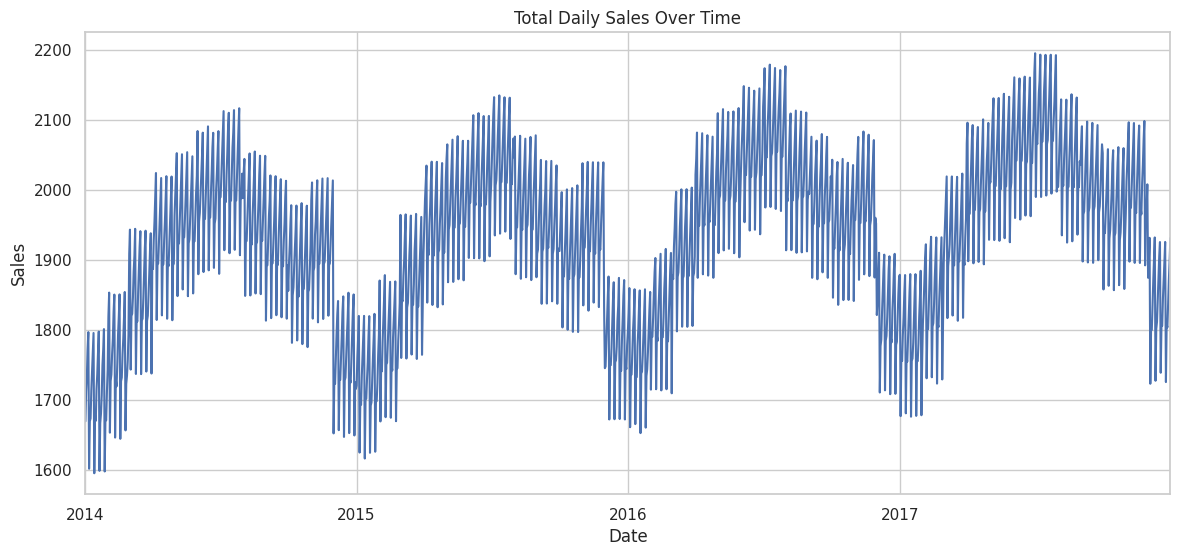

In [1]:
# =========================================================
# 📦 1. Imports
# =========================================================
import numpy as np
import pandas as pd
from datetime import timedelta
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# =========================================================
# 📂 2. Load Data
# =========================================================
train = pd.read_csv('/kaggle/input/datasets/jurijsruko/analytics/train.csv')
test = pd.read_csv('/kaggle/input/datasets/jurijsruko/analytics/test.csv')
 

train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])

# =========================================================
# 🔧 3. Feature Engineering
# =========================================================
def create_features(df):
    df['dayofweek'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofmonth'] = df['date'].dt.day
    df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
    
    # Cyclical encoding
    df['sin_dow'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['cos_dow'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    
    return df

train = create_features(train)
test = create_features(test)

# =========================================================
# ⏳ 4. Lag Features
# =========================================================
def create_lag_features(df, lags=[7, 14, 28, 365]):
    df = df.sort_values(['store', 'item', 'date'])
    for lag in lags:
        df[f'lag_{lag}'] = df.groupby(['store','item'])['sales'].shift(lag)
    return df

train = create_lag_features(train)

# Rolling features
def create_rolling_features(df):
    df = df.sort_values(['store','item','date'])
    df['rmean_7'] = df.groupby(['store','item'])['sales'].shift(1).rolling(7).mean()
    df['rmean_30'] = df.groupby(['store','item'])['sales'].shift(1).rolling(30).mean()
    return df

train = create_rolling_features(train)

# Drop NA from lags
train = train.dropna()

# =========================================================
# 🎯 5. Target Transform
# =========================================================
train['sales'] = np.log1p(train['sales'])

# =========================================================
# ✂️ 6. Train/Validation Split
# =========================================================
cutoff = train['date'].max() - timedelta(days=90)

train_df = train[train['date'] <= cutoff]
val_df = train[train['date'] > cutoff]

features = [col for col in train.columns if col not in ['date','sales']]

X_train = train_df[features]
y_train = train_df['sales']

X_val = val_df[features]
y_val = val_df['sales']

# =========================================================
# 🌲 7. Model (LightGBM)
# =========================================================
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='l1',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

# 
  # =========================================================
# 🔁 8. Recursive Forecasting (FIXED)
# =========================================================

# Prepare full dataset
full = pd.concat([train, test], sort=False)
full = full.sort_values(['store', 'item', 'date']).reset_index(drop=True)

# Ensure sales exists
full['sales'] = full['sales']

# Create empty columns for lags
lags = [7, 14, 28, 365]

for lag in lags:
    full[f'lag_{lag}'] = np.nan

full['rmean_7'] = np.nan
full['rmean_30'] = np.nan

preds = []

# Iterate over each test date
for date in test['date'].sort_values().unique():
    
    mask = full['date'] == date
    df_day = full.loc[mask].copy()
    
    # Create lag features safely
    for lag in lags:
        full[f'lag_{lag}'] = full.groupby(['store','item'])['sales'].shift(lag)
        df_day[f'lag_{lag}'] = full.loc[mask, f'lag_{lag}']
    
    # Rolling features
    full['rmean_7'] = full.groupby(['store','item'])['sales'].shift(1).rolling(7).mean()
    full['rmean_30'] = full.groupby(['store','item'])['sales'].shift(1).rolling(30).mean()
    
    df_day['rmean_7'] = full.loc[mask, 'rmean_7']
    df_day['rmean_30'] = full.loc[mask, 'rmean_30']
    
    # Date features
    df_day = create_features(df_day)
    
    X_test = df_day[features]
    
    pred_log = model.predict(X_test)
    pred = np.expm1(pred_log)
    
    preds.extend(pred)
    
    # 🔑 Update full dataframe (CRITICAL)
    full.loc[mask, 'sales'] = pred_log  # keep log scale!

# =========================================================

# =========================================================
# 📤 9. Submission
# =========================================================
submission = test.copy()
submission['sales'] = preds

submission[['id','sales']].to_csv('submission.csv', index=False)

print("Submission file created!")
# =========================================================
# 📊 10. Visualization
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (14,6)

# Total daily sales
daily_sales = train.groupby('date')['sales'].sum()

plt.figure()
daily_sales.plot()
plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

## 1.Overall Sales Trend 

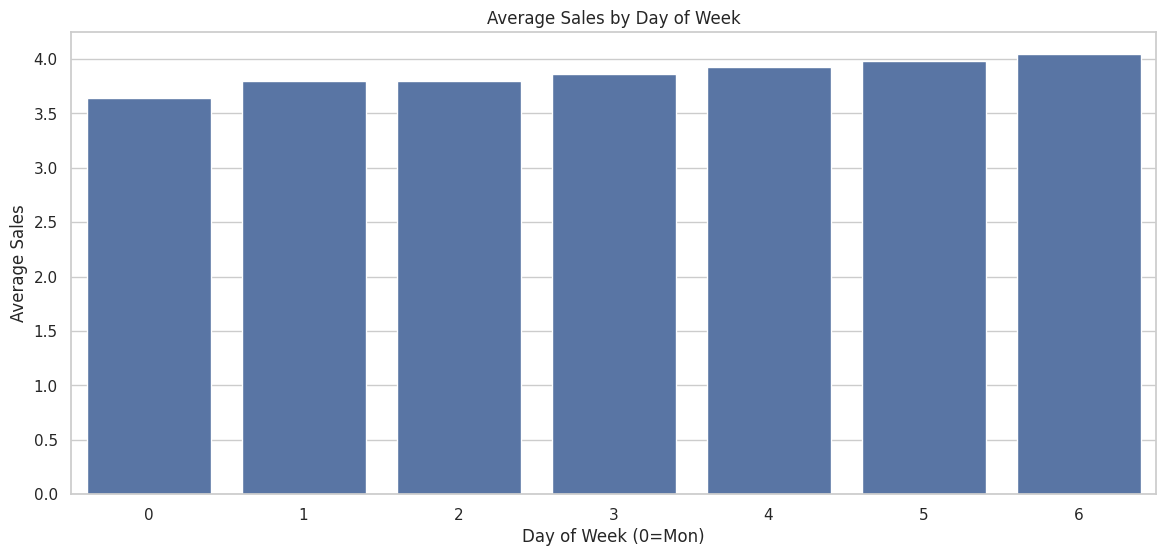

In [2]:
train['dayofweek'] = train['date'].dt.dayofweek

weekly = train.groupby('dayofweek')['sales'].mean()

plt.figure()
sns.barplot(x=weekly.index, y=weekly.values)
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Average Sales")
plt.show()

**What to look for:**

- Trend over years
- Repeating yearly patterns

## 2.Weekly Seasonality

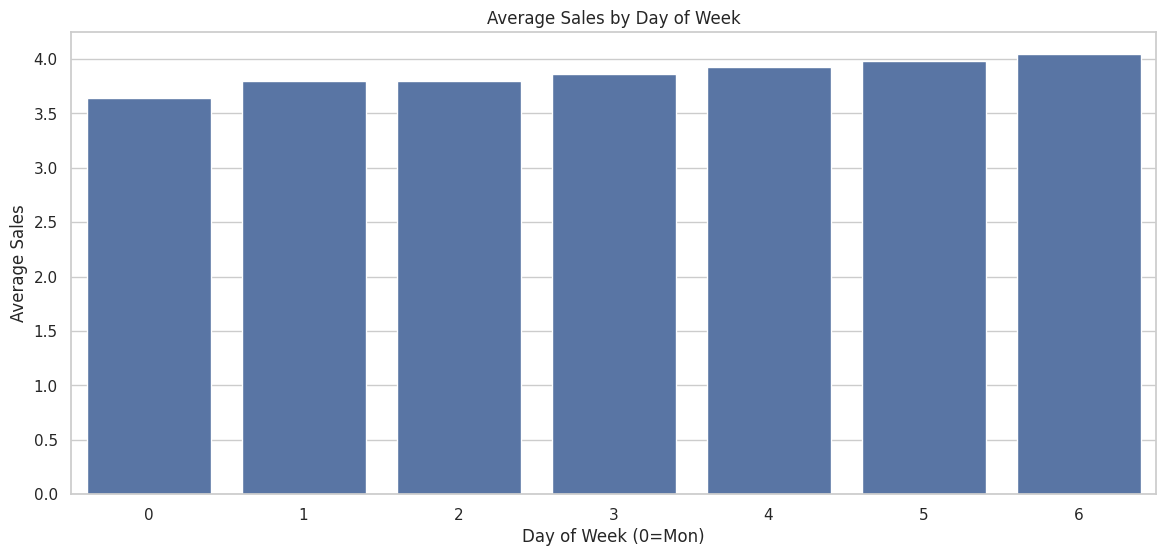

In [3]:
train['dayofweek'] = train['date'].dt.dayofweek

weekly = train.groupby('dayofweek')['sales'].mean()

plt.figure()
sns.barplot(x=weekly.index, y=weekly.values)
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Average Sales")
plt.show()

**Usually:**

- Weekends behave differently

## 3.Monthly Seasonality

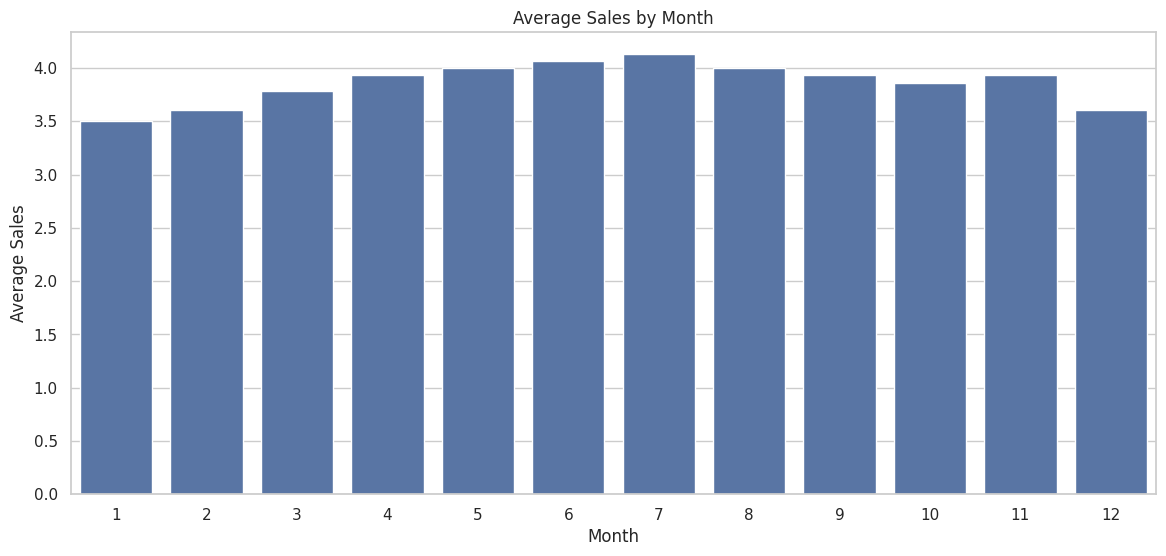

In [4]:
train['month'] = train['date'].dt.month

monthly = train.groupby('month')['sales'].mean()

plt.figure()
sns.barplot(x=monthly.index, y=monthly.values)
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

## 4.Store Comparison

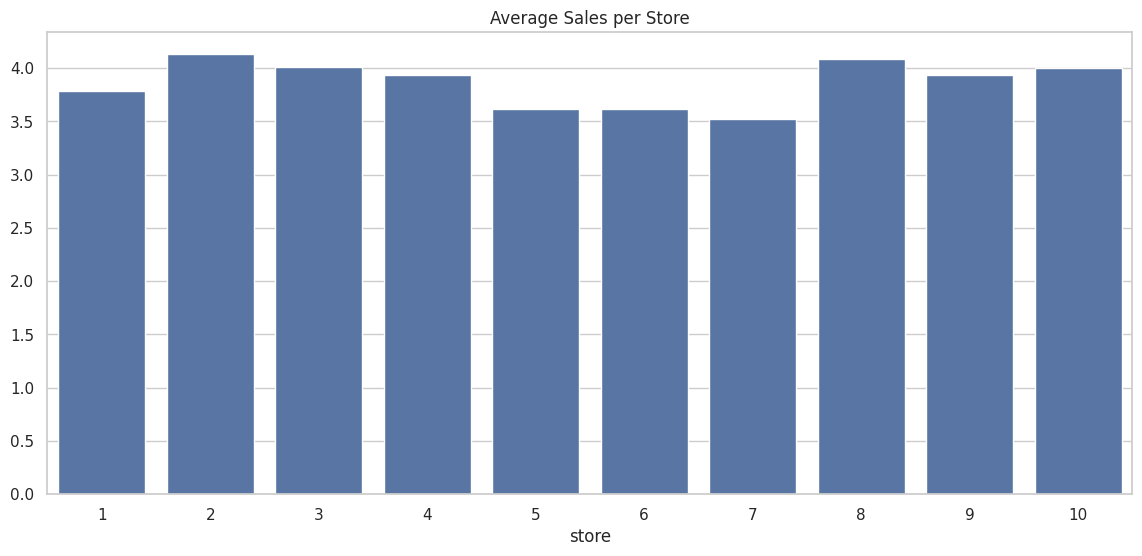

In [5]:
store_sales = train.groupby('store')['sales'].mean()

plt.figure()
sns.barplot(x=store_sales.index, y=store_sales.values)
plt.title("Average Sales per Store")
plt.show()

## 5.Item Distribution

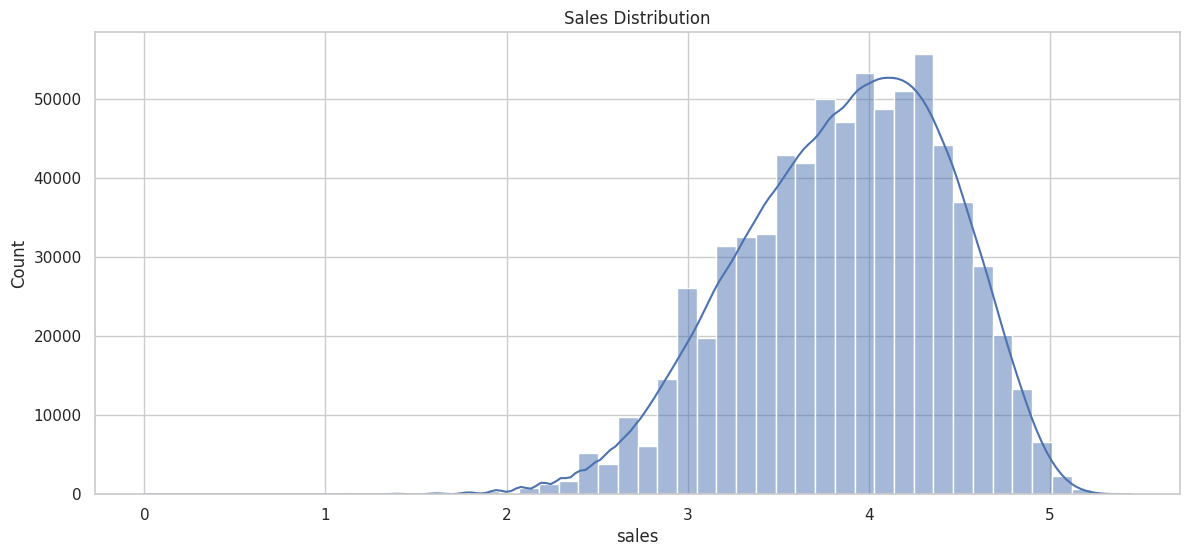

In [6]:
plt.figure()
sns.histplot(train['sales'], bins=50, kde=True)
plt.title("Sales Distribution")
plt.show()

**You’ll see:**

- Right-skew → justifies `log1p`

## 6.Heatmap (Store × Item)

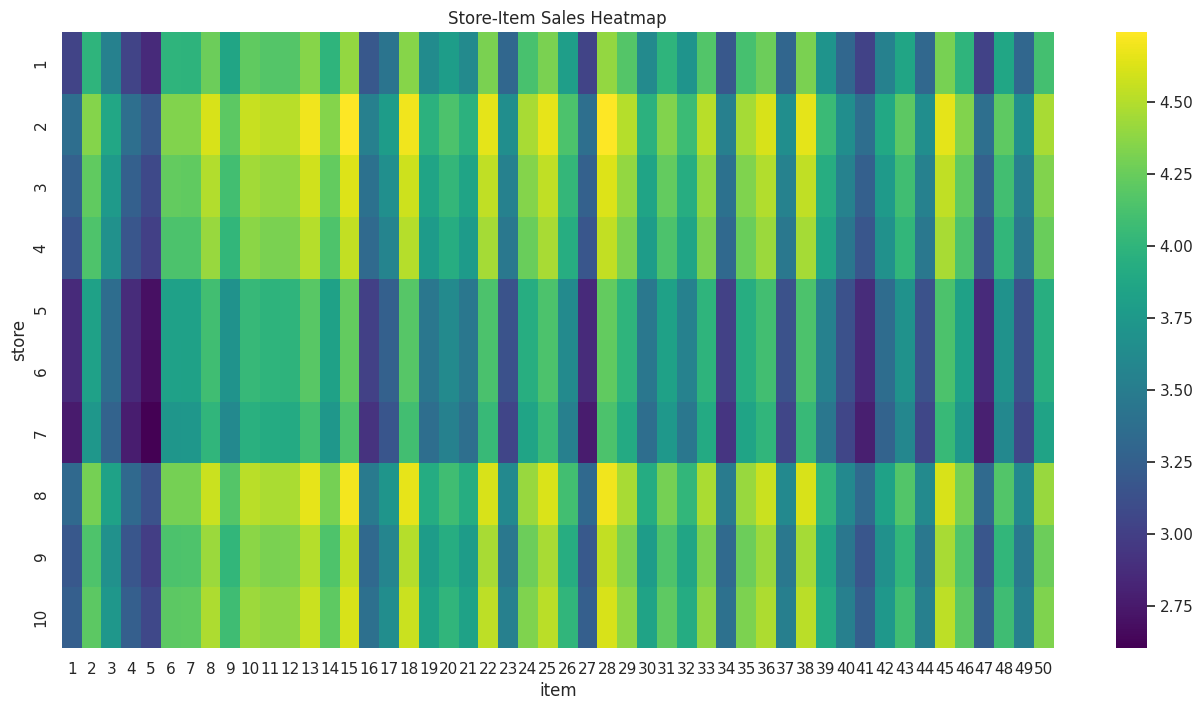

In [7]:
pivot = train.pivot_table(values='sales', index='store', columns='item')

plt.figure(figsize=(16,8))
sns.heatmap(pivot, cmap='viridis')
plt.title("Store-Item Sales Heatmap")
plt.show()

## 7.Prediction vs Actual (Validation)

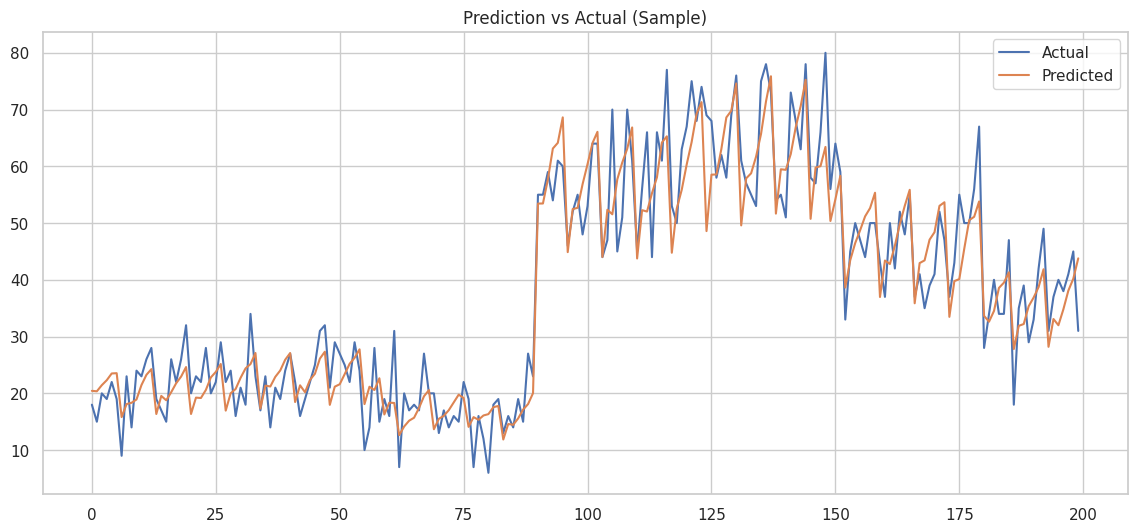

In [8]:
# Predict on validation
val_pred = model.predict(X_val)
val_pred = np.expm1(val_pred)
y_true = np.expm1(y_val)

plt.figure()
plt.plot(y_true.values[:200], label='Actual')
plt.plot(val_pred[:200], label='Predicted')
plt.legend()
plt.title("Prediction vs Actual (Sample)")
plt.show()

## 8.Residual Analysis

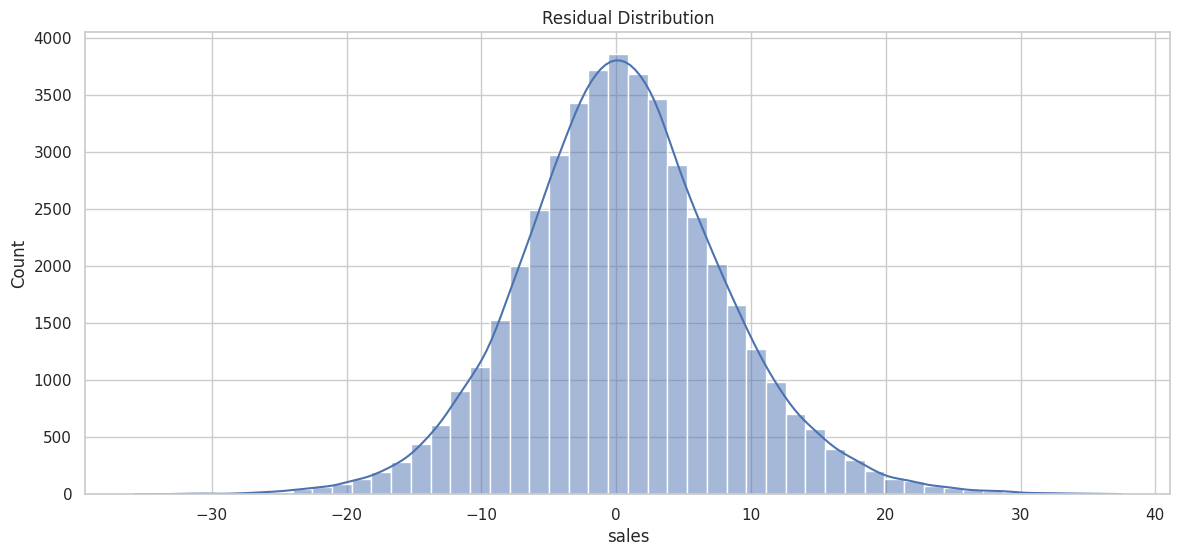

In [9]:
residuals = y_true - val_pred

plt.figure()
sns.histplot(residuals, bins=50, kde=True)
plt.title("Residual Distribution")
plt.show()

**Good model:**

- Centered around 0
- No heavy skew

## 9.Feature Importance

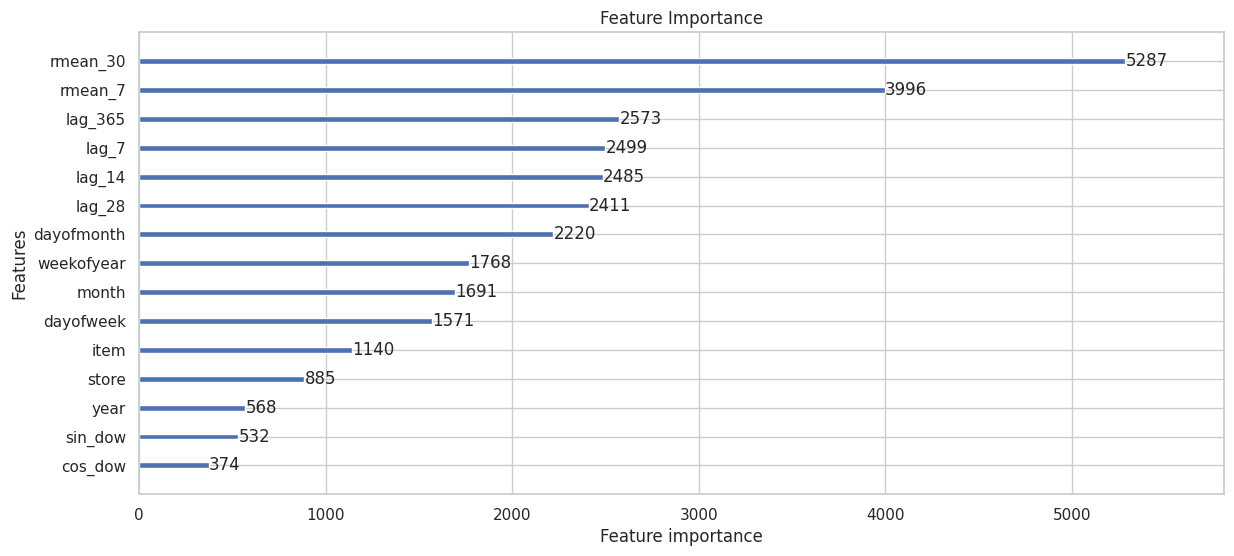

In [10]:
lgb.plot_importance(model, max_num_features=20)
plt.title("Feature Importance")
plt.show()

**You’ll usually see:**

- lag_7, lag_14 → VERY strong
- rolling means
- day_of_week

## 10.Single Time Series Example

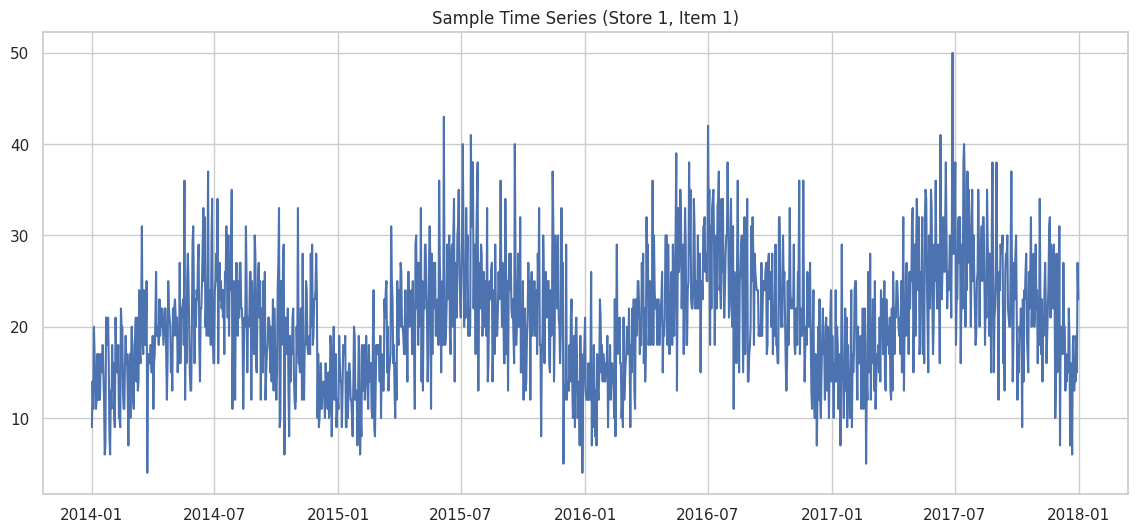

In [11]:
sample_series = train[(train['store']==1) & (train['item']==1)]

plt.figure()
plt.plot(sample_series['date'], np.expm1(sample_series['sales']))
plt.title("Sample Time Series (Store 1, Item 1)")
plt.show()

## Interactive sales trend

In [12]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "iframe"
daily_sales = train.groupby('date')['sales'].sum().reset_index()

fig = px.line(
    daily_sales, 
    x='date', 
    y='sales',
    title='📈 Total Sales Over Time (Interactive)'
)

fig.show()

## Filter by store

In [13]:
store_df = train.groupby(['date','store'])['sales'].sum().reset_index()

fig = px.line(
    store_df,
    x='date',
    y='sales',
    color='store',
    title='🏪 Sales by Store (Interactive)'
)

fig.show()

## Filter by product

In [14]:
item_df = train.groupby(['date','item'])['sales'].mean().reset_index()

fig = px.line(
    item_df,
    x='date',
    y='sales',
    color='item',
    title='📦 Sales by Item (Interactive)'
)

fig.show()

## Decomposition (Trend / Seasonality)

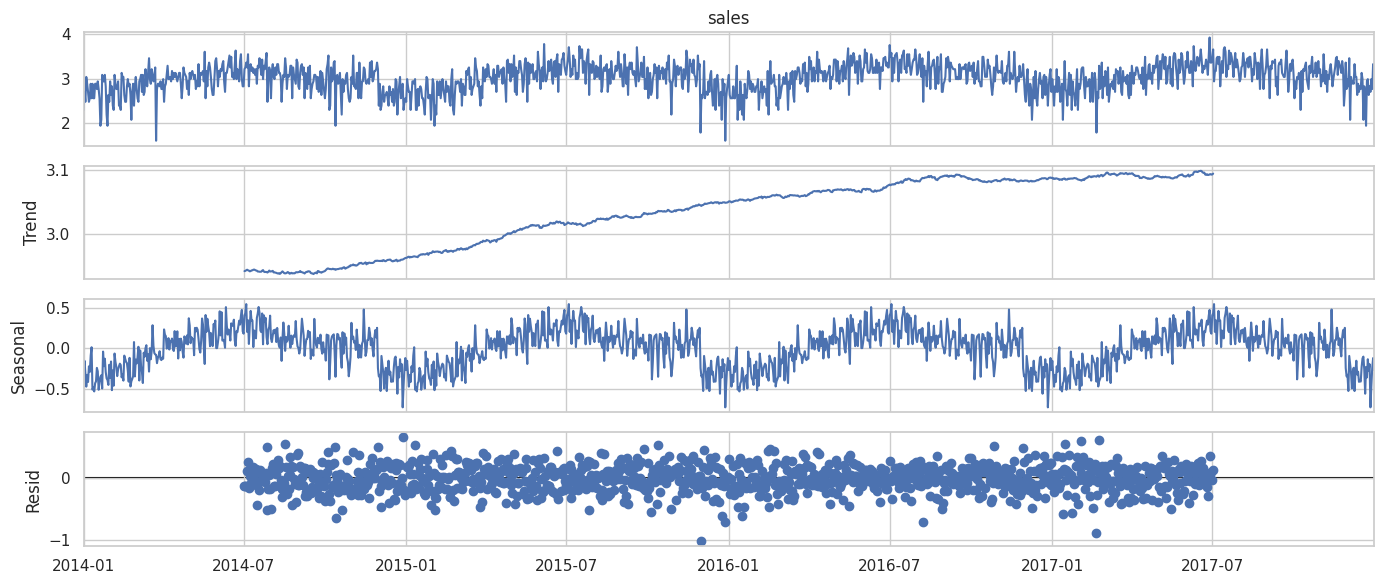

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Let's take one store-item
series = train[(train['store']==1) & (train['item']==1)].copy()

series = series.sort_values('date')
series.set_index('date', inplace=True)

result = seasonal_decompose(series['sales'], model='additive', period=365)

result.plot()
plt.show()

**What we see:**
- Trend → long-term growth
- Seasonal → repeating patterns
- Residual → noise

## An alternative (faster and better) is STL

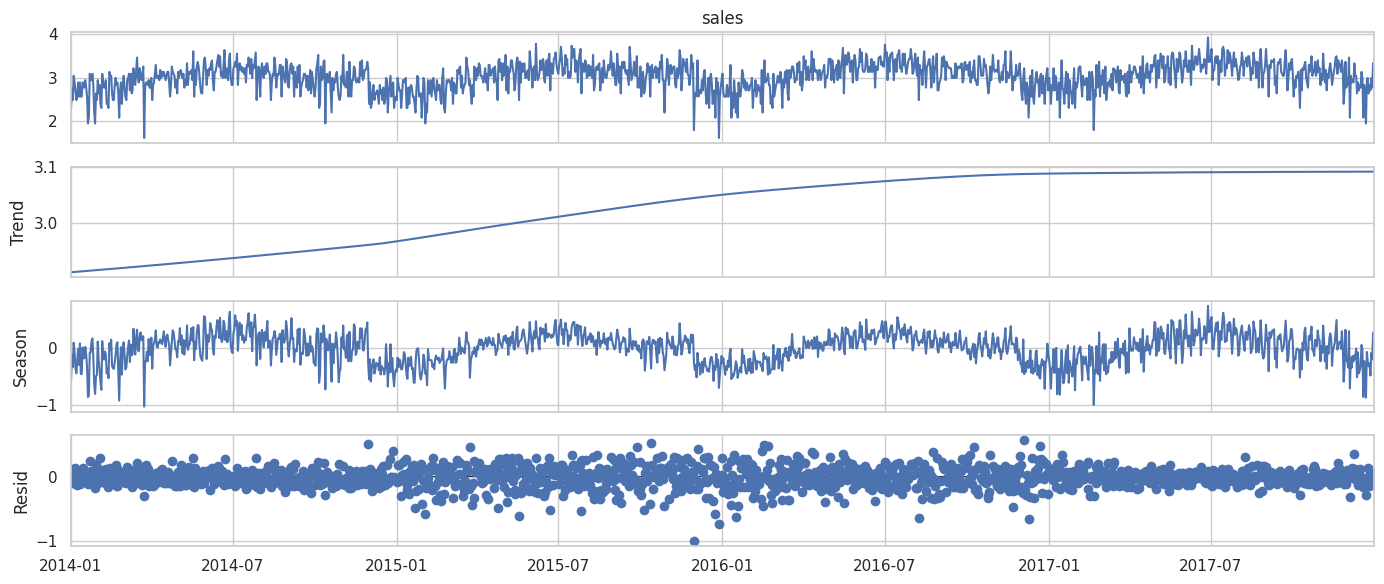

In [16]:
from statsmodels.tsa.seasonal import STL

stl = STL(series['sales'], period=365)
res = stl.fit()

res.plot()
plt.show()

## Error analysis

**SMAPE function**

In [17]:
def smape(y_true, y_pred):
    return np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )

## Error in stores

In [18]:
val_results = val_df.copy()

val_results['pred'] = val_pred
val_results['actual'] = y_true

store_errors = val_results.groupby('store').apply(
    lambda x: smape(x['actual'], x['pred'])
).reset_index(name='SMAPE')

fig = px.bar(
    store_errors,
    x='store',
    y='SMAPE',
    title='🏪 SMAPE by Store'
)

fig.show()

## Error with products

In [19]:
item_errors = val_results.groupby('item').apply(
    lambda x: smape(x['actual'], x['pred'])
).reset_index(name='SMAPE')

fig = px.histogram(
    item_errors,
    x='SMAPE',
    nbins=30,
    title='📦 Error Distribution Across Items'
)

fig.show()

## Error Heatmap (Store × Item)

In [20]:
heatmap_df = val_results.copy()

heatmap_df = heatmap_df.groupby(['store','item']).apply(
    lambda x: smape(x['actual'], x['pred'])
).reset_index(name='SMAPE')

pivot = heatmap_df.pivot(index='store', columns='item', values='SMAPE')

fig = px.imshow(
    pivot,
    title='🔥 SMAPE Heatmap (Store vs Item)',
    color_continuous_scale='RdYlGn_r'
)

fig.show()

## Errors in time

In [21]:
time_error = val_results.groupby('date').apply(
    lambda x: smape(x['actual'], x['pred'])
).reset_index(name='SMAPE')

fig = px.line(
    time_error,
    x='date',
    y='SMAPE',
    title='📉 Error Over Time'
)

fig.show()

## Distribution of Data Values by Year 

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 1️⃣ Extract year from date
train['year'] = train['date'].dt.year

# 2️⃣ Count the number of records per year
year_counts = train['year'].value_counts().sort_index()

fig = px.pie(
    values=year_counts.values,
    names=year_counts.index,
    title="Interactive Year Distribution"
)
fig.show()

## Results & Insights

 
- Gradient boosting models significantly outperform traditional statistical methods like ARIMA in this setting
- Lag and rolling features are the most important predictors
- Weekly seasonality is a dominant pattern across all stores and items
- Model performance varies across items, highlighting opportunities for further optimization

## Conclusion

This project demonstrates how time series forecasting problems can be effectively solved using machine learning techniques. By combining feature engineering, global modeling, and detailed analysis, it is possible to build scalable and accurate forecasting systems.